In [3]:
import numpy as np
from numpy import pi
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import cm
import itertools
colors = ['C0','C1','C2','C3','C4','C5','C6','C7','C8','C0','C1','C2','C3','C4','C5','C6','C7','C8']

from blochK.plotting import plot_FS, plot_bandstruc
from blochK.plotting.utils import sample_square, extent
from blochK.observable import exp_value_O,conductivity_orbital_resolved, local_dos_QPI, find_Gamma
import blochK

from alter_surf.hamiltonian_DLKK import create_H_DLKK_3D
from alter_surf.utils3D import projector2layer


from numpy import cos, sin 

In [ ]:
def H_2D_fct(kx,ky,t=1,M=1,mu=0): 
    """
    t: NN hopping
    tp: NNN hopping
    delta: unisotropy of NNN hopping [1,1], [-1,1] direction
    mu: chemical potential
    mAF: AF magnetization +m on A, -m on B
    mF: F magnetization +m on A, +m on B
    """
    Hk = np.zeros((2,2,*kx.shape),dtype=complex) #Basis (A up, B up, A down, B down)

    # #set hamiltonian structure
    Hk[0,1] = - 0*2*t*sin(kx) - 2j*t*sin(ky)
    Hk[0,0] = -mu  - 2*t* (cos(kx) + cos(ky)) - M
    Hk[1,1] = -mu  + 2*t* (cos(kx) + cos(ky)) + M

    # make hermitian
    Hk[1,0] = np.conjugate(Hk[0,1])

    # spin degenerate
    #Hk[2:,2:] = Hk[:2,:2]

    return Hk


def H_3D_fct(kx,ky,len_z=2,t=1,M=0,mu=0,PBC=False): 
    """
    len_z: number of layers in z-direction
    t: NN hopping
    tp: NNN hopping
    tz: NN hopping in [0,0,1] direction
    TODO: tzp: NNN hopping in [1,0,1],[-1,0,1],[0,1,1],[0,-1,1] direction
    delta: unisotropy of NNN hopping [1,1], [-1,1] direction
    delta_Q_z: wave vector of unisotropy -> typical values are 0 (stacked DLKK model), pi (alternating patterns of DLKK model)
    mu: chemical potential
    mAF (float or np.ndarray): AF magnetization +m on A, -m on B. If float, same m for all layers. If .shape=(len_z,), m[j] is the magnetization in layer j
    mF (float or np.ndarray):   F magnetization +m on A, +m on B. If float, same m for all layers. If .shape=(len_z,), m[j] is the magnetization in layer j
    """
    Hk = np.zeros((2*len_z,2*len_z,*kx.shape),dtype=complex)
    
    for j in range(len_z):
         Hk[2*j:2*j+2,2*j:2*j+2] = H_2D_fct(kx,ky,t=t,mu=mu,M=M)

    #extend to 3D
    #z-hoppings
    Hz = np.zeros((2,2,*kx.shape),dtype=complex)
    # (z=1,x,up), (z=1,y,up), (z=1,x,down), (z=1,y,down)  -> (z=0,x,up), (z=0,y,up), (z=0,x,down), (z=0,y,down)

    Hz[0,0] = -t
    Hz[1,1] = +t
    Hz[0,1] = -t
    Hz[1,0] = np.conjugate(Hz[0,1])
    #spin degenerate
    #Hz[2:,2:] = Hz[:2,:2]

    #add to final Hamiltonian
    for j in range(len_z-1):
        Hk[2*j:2*j+2,2*j+2:2*j+4] = Hz #upper block
        Hk[2*j+2:2*j+4,2*j:2*j+2] = Hz #lower block

    if PBC: # Periodic boundary conditions
        Hk[2*(len_z-1):2*len_z,0:2] = Hz
        Hk[0:2,2*(len_z-1):2*len_z] = Hz

    return Hk



Hparam0 = dict(len_z=11, M=1.8,mu=-0., PBC=False)
H = blochK.Hamiltonian2D(H_3D_fct, param=Hparam0)

H.add_suboperator('orbital',np.array([1,-1]))


 #set up Hamiltonian with fixed len_z because it defines n_orbitals



filling is:  0.5


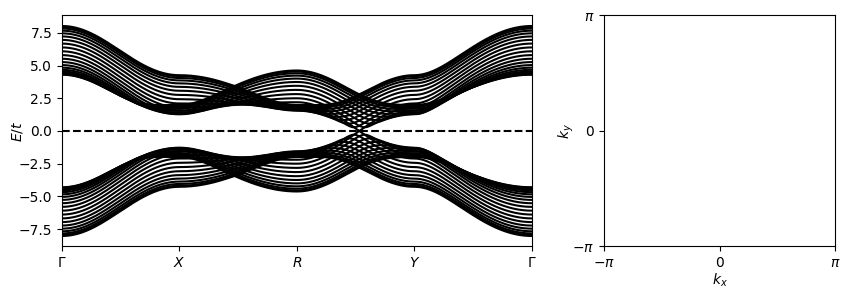

In [56]:

labels = ['\Gamma',"X","R","Y",'\Gamma']
coloring_operator = 0
cmap = 'bwr'


fig, [ax,ax1] = plt.subplots(1,2,gridspec_kw={'width_ratios': [2,1]},figsize=(10,3))
plot_bandstruc(ax,H,labels_points_path=labels,cmap=cmap)
plot_FS(ax1,H,cmap=cmap,Lk=50,print_filling=True)


In [60]:
Lq = 100 #number of k-points in each direction

# Define the k-point grid
ks = sample_square(Lq)
#Diagonalize Hamiltonian
es,psis = H.diagonalize(*ks)

def plot_spectral_density(ax,spectral_density,cmap='bwr',title_plot='',show_xlabel=True,show_ylabel=True,vmax='',vmin=''):
    """Plots colored spin spectral density on ax,

    cmap: a matplotlib colormap
    title_plot: title of the plot if given
    vmax: maximum value for color scaling
    """
    if title_plot!='':
         ax.set_title(title_plot,fontsize=6)
    ax.set_aspect('equal')
    if show_xlabel:
        ax.set_xlabel('$k_x$',labelpad=1)
        ax.set_xticks([-pi,0,pi])
        ax.set_xticklabels(['$-\pi$',0,'$\pi$'])
    else:
        ax.set_xticklabels([])
    if show_ylabel:
        ax.set_ylabel('$k_y$',labelpad=-2.5)
        ax.set_yticks([-pi,0,pi])
        ax.set_yticklabels(['$-\pi$',0,'$\pi$'])
    else:
        ax.set_yticklabels([])
    ax.set_xlim(-pi,pi)
    ax.set_ylim(-pi,pi)
    #--------------
    if vmax == '':
        vmax = np.abs(spectral_density).max()
    if vmin == '':
        vmin = -vmax
    im = ax.imshow(spectral_density,extent=(-pi,pi,-pi,pi),origin='lower',cmap=cmap,norm=matplotlib.colors.LogNorm(vmin=1e-5,vmax=vmax))
    return im




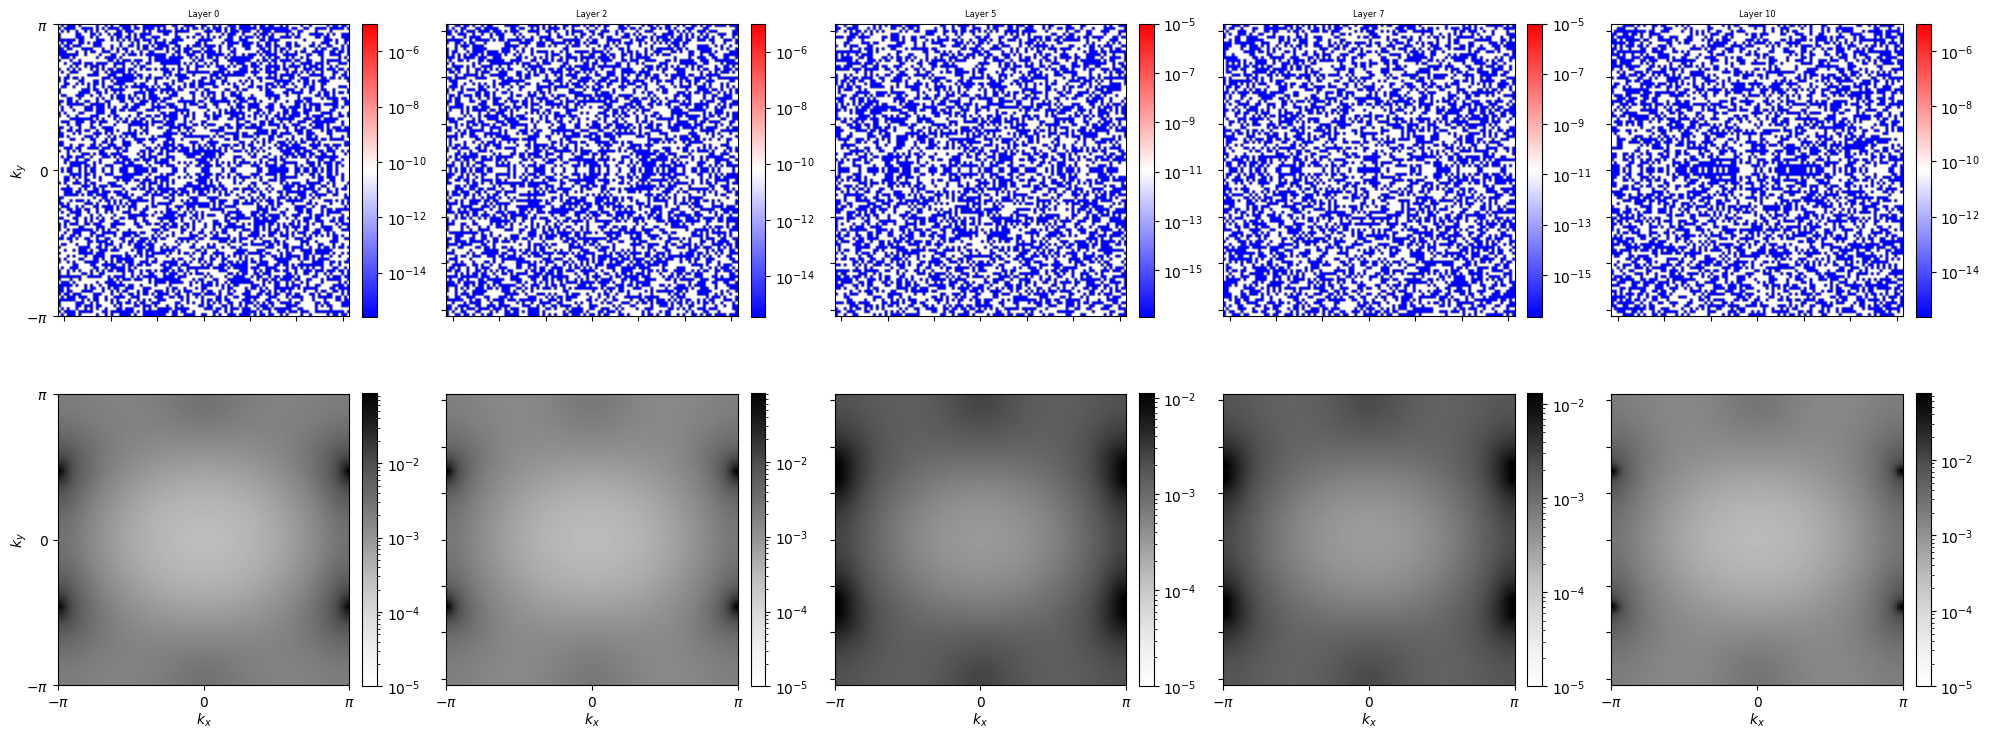

In [61]:
Gamma = find_Gamma(es)
len_z = Hparam0['len_z']
#layers = [0,len_z//6,len_z//3,len_z//2]
layers = np.linspace(0,len_z//2,5,dtype=int)


#Plot
fig,axs = plt.subplots(2,len(layers),figsize=(4*len(layers),8))

for ax_column,layer in zip(axs.T,layers):
    proj_2layers = projector2layer(layer,len_z=len_z)
    coloring_operator = np.kron(proj_2layers,H.suboperator.orbital) #projected spin_operator

    #compute spin spectral density
    Os = exp_value_O(coloring_operator,psis) #.shape=(n,y,x)
    spectral_density_spin = np.sum(Os*Gamma/(es**2+Gamma**2),axis=0)/len_z

    #compute spectral density
    Os = exp_value_O(np.kron(proj_2layers,np.ones(2)),psis) #.shape=(n,y,x)
    spectral_density0 = np.sum(Os*Gamma/(es**2+Gamma**2),axis=0)/len_z

    
    vmax_spin = np.abs(spectral_density_spin).max()
    vmax0 = np.abs(spectral_density0).max()

    imT = plot_spectral_density(ax_column[0],spectral_density_spin,title_plot='Layer '+str(layer),show_ylabel=(layer==0),show_xlabel=False,vmax=vmax_spin)
    imB = plot_spectral_density(ax_column[1],spectral_density0,show_ylabel=(layer==0),show_xlabel=True,vmax=vmax0,vmin=0,cmap='Greys')
    
    #colorbars for each plot
    plt.colorbar(imT,ax=ax_column[0],fraction=0.046,pad=0.04)
    plt.colorbar(imB,ax=ax_column[1],fraction=0.046,pad=0.04)    


# plt.colorbar(imT,ax=axs[0,-1],fraction=0.046,pad=0.04)
# plt.colorbar(imB,ax=axs[1,-1],fraction=0.046,pad=0.04)

plt.tight_layout()
